# 03 — Certification Engine

This notebook defines the Pydantic schemas, system prompts, LangGraph nodes, and
wires them into a complete `StateGraph` pipeline that generates certification artifacts.

## Pipeline Nodes
1. `retrieve_docs` — Qdrant retrieval + Tavily web search
2. `generate_competency_framework` — domains and skills for a certification track
3. `generate_learning_progression` — ordered learning path
4. `generate_assessments` — performance-based assessment scenarios
5. `generate_rubrics` — scoring criteria per assessment
6. `generate_item_bank` — item bank entries spanning all domains
7. `generate_blueprint` — executive summary tying all artifacts together

In [1]:
import os
import json
from pathlib import Path
from typing import TypedDict, Optional
from dotenv import load_dotenv

# Schemas (Section 1)
from pydantic import BaseModel, Field

# LLM, embeddings, vector store (Section 2)
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_qdrant import QdrantVectorStore
from langchain_core.messages import SystemMessage, HumanMessage

# Reranked retriever — winner from notebook 02 (Section 3)
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

# Tavily freshness check (Section 3)
from langchain_tavily import TavilySearch

# LangGraph pipeline (Section 4)
from langgraph.graph import StateGraph, START, END

# Graph visualization (Section 4)
from IPython.display import Image, display

load_dotenv(Path("../.env"))

QDRANT_URL = os.getenv("QDRANT_URL")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
COHERE_API_KEY = os.getenv("COHERE_API_KEY")
COLLECTION_NAME = "certops_docs"

## 1. Pydantic Schemas

Structured output models enforce that the LLM returns valid, typed JSON.
Using `.with_structured_output(Schema)` the LLM is constrained to the exact schema.

In [2]:
class Skill(BaseModel):
    name: str = Field(description="Name of the skill")
    description: str = Field(description="What this skill covers")
    proficiency_levels: list[str] = Field(
        description="Proficiency descriptors: novice, competent, expert",
        min_length=3, max_length=3,
    )


class Domain(BaseModel):
    name: str = Field(description="Domain name")
    description: str = Field(description="What this domain covers")
    skills: list[Skill] = Field(description="Skills within this domain", min_length=2)


class CompetencyFramework(BaseModel):
    track: str = Field(description="Certification track name")
    description: str = Field(description="Overview of what this certification validates")
    domains: list[Domain] = Field(description="Competency domains", min_length=3)


class LearningObjective(BaseModel):
    order: int = Field(description="Sequence order (1-based)")
    title: str = Field(description="Learning objective title")
    description: str = Field(description="What the learner will be able to do")
    domain: str = Field(description="Which competency domain this maps to")
    prerequisites: list[str] = Field(default_factory=list)


class LearningProgression(BaseModel):
    track: str = Field(description="Certification track name")
    objectives: list[LearningObjective] = Field(description="Ordered learning objectives")


class AssessmentTask(BaseModel):
    title: str = Field(description="Assessment task title")
    scenario: str = Field(description="Real-world scenario")
    instructions: str = Field(description="Detailed instructions")
    expected_outputs: list[str] = Field(description="What the candidate should produce")
    competency_ref: str = Field(description="Which skill/domain this assesses")
    time_estimate_minutes: int = Field(description="Estimated time to complete")


class AssessmentList(BaseModel):
    tasks: list[AssessmentTask] = Field(description="List of assessment tasks")


class RubricCriterion(BaseModel):
    criterion: str = Field(description="What is being evaluated")
    novice: str = Field(description="Novice-level descriptor")
    competent: str = Field(description="Competent-level descriptor")
    expert: str = Field(description="Expert-level descriptor")


class Rubric(BaseModel):
    assessment_ref: str = Field(description="Title of the assessment task")
    criteria: list[RubricCriterion] = Field(description="Evaluation criteria", min_length=3)


class RubricList(BaseModel):
    rubrics: list[Rubric] = Field(description="List of rubrics")


class ItemBankEntry(BaseModel):
    stem: str = Field(description="The question or task prompt")
    task_type: str = Field(description="performance, scenario, or analysis")
    competency_ref: str = Field(description="Skill/domain this item assesses")
    expected_response_summary: str = Field(description="Brief summary of correct response")
    scoring_notes: str = Field(description="Notes for evaluators")


class ItemBank(BaseModel):
    items: list[ItemBankEntry] = Field(description="Item bank entries")


class CertificationBlueprint(BaseModel):
    program_title: str = Field(description="Full certification program title")
    target_audience: str = Field(description="Who this certification is for")
    prerequisites: str = Field(description="What candidates should know before starting")
    program_overview: str = Field(description="2-3 paragraph program overview")
    domain_summary: list[str] = Field(description="One sentence summary per domain")
    assessment_strategy: str = Field(
        description="How candidates are assessed - format, approach, and philosophy"
    )
    estimated_duration_hours: float = Field(
        description="Total estimated hours to complete the certification"
    )
    renewal_cadence: str = Field(
        description="Recommended recertification interval and rationale"
    )


print("All schemas defined.")

All schemas defined.


## 2. Graph State and Helpers

In [3]:
class CertOpsState(TypedDict):
    track: str
    documents: list[str]
    tavily_context: str
    competency_framework: Optional[dict]
    learning_progression: Optional[dict]
    assessments: Optional[list[dict]]
    rubrics: Optional[list[dict]]
    item_bank: Optional[list[dict]]
    blueprint: Optional[dict]


embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

llm = ChatOpenAI(model="gpt-4o", temperature=0)

print("State and helpers ready.")

State and helpers ready.


## 3. Node Functions

Each node reads from the shared `CertOpsState` and returns a dict of state updates.
The retriever uses the **Cohere reranked strategy** — the winner from notebook 02
(retrieve top 20, rerank to top 5 with `rerank-v3.5`).

In [4]:
def retrieve_docs(state: CertOpsState) -> dict:
    """Retrieve top-20 from Qdrant, rerank to top-5 with Cohere, plus Tavily freshness check."""
    track = state["track"]
    query = f"{track} certification competencies and skills"

    wide_retriever = vector_store.as_retriever(search_kwargs={"k": 20})
    compressor = CohereRerank(model="rerank-v3.5", top_n=5)
    reranked_retriever = ContextualCompressionRetriever(
        base_compressor=compressor,
        base_retriever=wide_retriever,
    )
    docs = reranked_retriever.invoke(query)
    doc_texts = [doc.page_content for doc in docs]

    tavily = TavilySearch(max_results=3)
    try:
        search_query = TRACK_SEARCH_QUERIES.get(track, f"{track} latest updates 2026")
        tavily_results = tavily.invoke(search_query)
        tavily_context = str(tavily_results)[:2000]
    except Exception:
        tavily_context = ""

    return {"documents": doc_texts, "tavily_context": tavily_context}


def check_documents(state: CertOpsState) -> str:
    """Conditional edge: retry if insufficient documents."""
    if len(state.get("documents", [])) < 3:
        return "retry_retrieve"
    return "generate"


TRACK_SEARCH_QUERIES = {
    "AI Champion": "Microsoft Copilot Studio latest updates 2026",
    "M365 Copilot User": "Microsoft 365 Copilot latest updates 2026",
}

TRACK_DOMAIN_HINTS = {
    "AI Champion": (
        "Include at least 4 domains covering agent creation & configuration, "
        "conversational design, connectors/integrations, and security/governance."
    ),
    "M365 Copilot User": (
        "Include at least 4 domains covering productivity (Word, Excel, PowerPoint), "
        "communication (Teams, Outlook), data analysis, and prompting best practices."
    ),
}


def generate_competency_framework(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(CompetencyFramework)
    context = "\n\n".join(state["documents"])
    domain_hint = TRACK_DOMAIN_HINTS.get(state["track"], "Include at least 4 relevant domains.")
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are an expert certification architect specializing in enterprise AI platforms. "
            "Using the provided documentation context, generate a comprehensive competency framework "
            f"for the specified track. {domain_hint}\n\n"
            f"Context:\n{context}\n\nLatest updates:\n{state.get('tavily_context', '')}"
        )),
        HumanMessage(content=f"Generate a competency framework for: {state['track']}"),
    ])
    return {"competency_framework": response.model_dump()}


def generate_learning_progression(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(LearningProgression)
    fw_str = json.dumps(state["competency_framework"], indent=2)
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are an instructional designer. Create an ordered learning progression "
            "from this framework. Earlier objectives are prerequisites for later ones."
        )),
        HumanMessage(content=f"Create learning progression for:\n{fw_str}"),
    ])
    return {"learning_progression": response.model_dump()}


def generate_assessments(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(AssessmentList)
    fw_str = json.dumps(state["competency_framework"], indent=2)
    context = "\n\n".join(state["documents"][:5])
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are an assessment designer. Generate performance-based tasks that evaluate "
            f"real competence, not just recall.\n\nFramework:\n{fw_str}\n\nContext:\n{context}"
        )),
        HumanMessage(content="Generate one assessment task per domain."),
    ])
    return {"assessments": [t.model_dump() for t in response.tasks]}


def generate_rubrics(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(RubricList)
    assessments_str = json.dumps(state["assessments"], indent=2)
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are an expert in rubric design. Create scoring rubrics with "
            "novice/competent/expert descriptors for consistent inter-rater reliability."
        )),
        HumanMessage(content=f"Create rubrics for:\n{assessments_str}"),
    ])
    return {"rubrics": [r.model_dump() for r in response.rubrics]}


def generate_item_bank(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(ItemBank)
    fw_str = json.dumps(state["competency_framework"], indent=2)
    context = "\n\n".join(state["documents"][:5])
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are an expert item writer. Generate performance/scenario/analysis items "
            f"(NOT multiple choice).\n\nFramework:\n{fw_str}\n\nContext:\n{context}"
        )),
        HumanMessage(content="Generate 10 item bank entries spanning all domains."),
    ])
    return {"item_bank": [item.model_dump() for item in response.items]}


def generate_blueprint(state: CertOpsState) -> dict:
    structured_llm = llm.with_structured_output(CertificationBlueprint)
    summary = {
        "track": state["track"],
        "framework": state["competency_framework"],
        "num_objectives": len(state["learning_progression"]["objectives"]),
        "num_assessments": len(state["assessments"]),
        "num_rubrics": len(state["rubrics"]),
        "num_items": len(state["item_bank"]),
    }
    response = structured_llm.invoke([
        SystemMessage(content=(
            "You are a certification program director writing an executive summary of a "
            "certification program. Synthesize all the artifacts that have been generated "
            "into a cohesive Certification Blueprint.\n\n"
            "The blueprint should read like a document you'd present to a VP of Learning & "
            "Development to get buy-in for launching this certification program. "
            "The program_overview should be 2-3 substantive paragraphs. "
            "The assessment_strategy should explain the philosophy (performance-based, not "
            "multiple choice) and how it maps to real-world competence."
        )),
        HumanMessage(content=f"Create a certification blueprint from:\n{json.dumps(summary, indent=2)}"),
    ])
    return {"blueprint": response.model_dump()}


print("All node functions defined.")

All node functions defined.


## 4. Build the StateGraph

Linear pipeline with a conditional edge after retrieval (retry if < 3 docs).

In [5]:
builder = StateGraph(CertOpsState)

builder.add_node("retrieve_docs", retrieve_docs)
builder.add_node("generate_competency_framework", generate_competency_framework)
builder.add_node("generate_learning_progression", generate_learning_progression)
builder.add_node("generate_assessments", generate_assessments)
builder.add_node("generate_rubrics", generate_rubrics)
builder.add_node("generate_item_bank", generate_item_bank)
builder.add_node("generate_blueprint", generate_blueprint)

builder.add_edge(START, "retrieve_docs")
builder.add_conditional_edges(
    "retrieve_docs",
    check_documents,
    {"retry_retrieve": "retrieve_docs", "generate": "generate_competency_framework"},
)
builder.add_edge("generate_competency_framework", "generate_learning_progression")
builder.add_edge("generate_learning_progression", "generate_assessments")
builder.add_edge("generate_assessments", "generate_rubrics")
builder.add_edge("generate_rubrics", "generate_item_bank")
builder.add_edge("generate_item_bank", "generate_blueprint")
builder.add_edge("generate_blueprint", END)

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


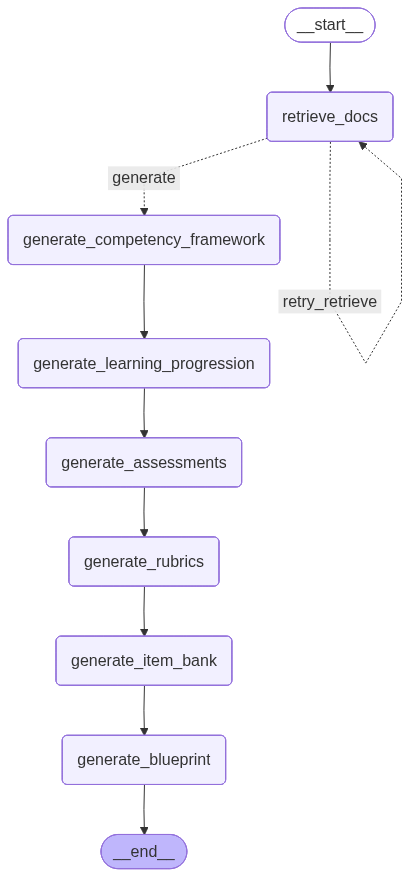

In [6]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render: {e}")
    print(graph.get_graph().draw_mermaid())

## 5. Run End-to-End — AI Champion Track

In [7]:
initial_state: CertOpsState = {
    "track": "AI Champion",
    "documents": [],
    "tavily_context": "",
    "competency_framework": None,
    "learning_progression": None,
    "assessments": None,
    "rubrics": None,
    "item_bank": None,
    "blueprint": None,
}

print("Running CertOps pipeline for AI Champion track...\n")
final_state = graph.invoke(initial_state)

print("\nPipeline complete!")
print(f"  Documents retrieved: {len(final_state['documents'])}")
print(f"  Framework domains: {len(final_state['competency_framework']['domains'])}")
print(f"  Learning objectives: {len(final_state['learning_progression']['objectives'])}")
print(f"  Assessments: {len(final_state['assessments'])}")
print(f"  Rubrics: {len(final_state['rubrics'])}")
print(f"  Item bank entries: {len(final_state['item_bank'])}")
print(f"  Blueprint: {final_state['blueprint']['program_title']}")

Running CertOps pipeline for AI Champion track...



/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CompetencyFramework(track...mpetent', 'expert'])])]), input_type=CompetencyFramework])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=LearningProgression(track...vacy and Compliance'])]), input_type=LearningProgression])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializa


Pipeline complete!
  Documents retrieved: 5
  Framework domains: 4
  Learning objectives: 12
  Assessments: 4
  Rubrics: 4
  Item bank entries: 10
  Blueprint: AI Champion Certification


/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CertificationBlueprint(pr...fessional development.'), input_type=CertificationBlueprint])
  return self.__pydantic_serializer__.to_python(


## 6. Inspect Outputs

In [8]:
fw = final_state["competency_framework"]
print("COMPETENCY FRAMEWORK")
print("=" * 60)
print(f"{fw['track']}")
print(f"{fw['description']}\n")
for domain in fw["domains"]:
    print(f"  Domain: {domain['name']}")
    for skill in domain["skills"]:
        print(f"    - {skill['name']}")

print("\n\nASSESSMENT TASKS")
print("=" * 60)
for t in final_state["assessments"]:
    print(f"  {t['title']} ({t['time_estimate_minutes']}min)")
    print(f"    Scenario: {t['scenario'][:100]}...")

print("\n\nITEM BANK (first 5)")
print("=" * 60)
for item in final_state["item_bank"][:5]:
    print(f"  [{item['task_type']}] {item['stem'][:80]}...")

COMPETENCY FRAMEWORK
AI Champion
This certification validates the ability to design, implement, and manage AI-driven solutions within an enterprise environment, focusing on agent creation, conversational design, integration, and security.

  Domain: Agent Creation & Configuration
    - Agent Configuration
    - Action and Workflow Definition
    - Trigger Management
  Domain: Conversational Design
    - Intent and Topic Management
    - Evaluation and Testing
    - User Engagement Analysis
  Domain: Connectors/Integrations
    - Channel Deployment
    - External System Integration
    - API Management
  Domain: Security & Governance
    - Agent Authentication
    - Data Privacy and Compliance
    - Responsible AI Implementation


ASSESSMENT TASKS
  Configure an AI Agent for Customer Support (90min)
    Scenario: You are tasked with setting up an AI agent for a retail company to handle customer inquiries about o...
  Design a Conversational Flow for a Banking Chatbot (120min)
    Scenar

## 7. Run End-to-End — M365 Copilot User Track

In [9]:
user_state: CertOpsState = {
    "track": "M365 Copilot User",
    "documents": [],
    "tavily_context": "",
    "competency_framework": None,
    "learning_progression": None,
    "assessments": None,
    "rubrics": None,
    "item_bank": None,
    "blueprint": None,
}

print("Running CertOps pipeline for M365 Copilot User track...\n")
user_result = graph.invoke(user_state)

print("\nPipeline complete!")
print(f"  Documents retrieved: {len(user_result['documents'])}")
print(f"  Framework domains: {len(user_result['competency_framework']['domains'])}")
print(f"  Learning objectives: {len(user_result['learning_progression']['objectives'])}")
print(f"  Assessments: {len(user_result['assessments'])}")
print(f"  Rubrics: {len(user_result['rubrics'])}")
print(f"  Item bank entries: {len(user_result['item_bank'])}")
print(f"  Blueprint: {user_result['blueprint']['program_title']}")

Running CertOps pipeline for M365 Copilot User track...



/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CompetencyFramework(track...or complex tasks.'])])]), input_type=CompetencyFramework])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=LearningProgression(track...ciency with Copilot'])]), input_type=LearningProgression])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializa


Pipeline complete!
  Documents retrieved: 5
  Framework domains: 4
  Learning objectives: 23
  Assessments: 4
  Rubrics: 4
  Item bank entries: 10
  Blueprint: Microsoft 365 Copilot User Certification


/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CertificationBlueprint(pr...nd productivity tools.'), input_type=CertificationBlueprint])
  return self.__pydantic_serializer__.to_python(


## 8. Side-by-Side Comparison

In [10]:
ai_result = final_state

print(f"{'Metric':<25} {'AI Champion':>15} {'User':>15}")
print("=" * 55)

metrics = [
    ("Domains", len(ai_result["competency_framework"]["domains"]), len(user_result["competency_framework"]["domains"])),
    ("Learning objectives", len(ai_result["learning_progression"]["objectives"]), len(user_result["learning_progression"]["objectives"])),
    ("Assessment tasks", len(ai_result["assessments"]), len(user_result["assessments"])),
    ("Rubrics", len(ai_result["rubrics"]), len(user_result["rubrics"])),
    ("Item bank entries", len(ai_result["item_bank"]), len(user_result["item_bank"])),
    ("Blueprint domains", len(ai_result["blueprint"]["domain_summary"]), len(user_result["blueprint"]["domain_summary"])),
    ("Est. duration (hrs)", ai_result["blueprint"]["estimated_duration_hours"], user_result["blueprint"]["estimated_duration_hours"]),
]

for label, ai_val, user_val in metrics:
    print(f"{label:<25} {ai_val:>15} {user_val:>15}")

Metric                        AI Champion            User
Domains                                 4               4
Learning objectives                    12              23
Assessment tasks                        4               4
Rubrics                                 4               4
Item bank entries                      10              10
Blueprint domains                       4               4
Est. duration (hrs)                  40.0            40.0


In [11]:
print("AI CHAMPION — Framework Domains:")
for d in ai_result["competency_framework"]["domains"]:
    print(f"  {d['name']}: {', '.join(s['name'] for s in d['skills'])}")

print("\nUSER — Framework Domains:")
for d in user_result["competency_framework"]["domains"]:
    print(f"  {d['name']}: {', '.join(s['name'] for s in d['skills'])}")

AI CHAMPION — Framework Domains:
  Agent Creation & Configuration: Agent Configuration, Action and Workflow Definition, Trigger Management
  Conversational Design: Intent and Topic Management, Evaluation and Testing, User Engagement Analysis
  Connectors/Integrations: Channel Deployment, External System Integration, API Management
  Security & Governance: Agent Authentication, Data Privacy and Compliance, Responsible AI Implementation

USER — Framework Domains:
  Productivity Tools: Word with Copilot, Excel with Copilot, PowerPoint with Copilot
  Communication Tools: Teams with Copilot, Outlook with Copilot
  Data Analysis: Data Insights with Copilot, Integration with Data Sources
  Prompting Best Practices: Prompt Design, Prompt Optimization


## 9. Export Both Tracks

In [12]:
output_dir = Path("../data")
output_dir.mkdir(exist_ok=True)

for name, result in [("ai_champion", ai_result), ("user", user_result)]:
    outputs = {
        "competency_framework": result["competency_framework"],
        "learning_progression": result["learning_progression"],
        "assessments": result["assessments"],
        "rubrics": result["rubrics"],
        "item_bank": result["item_bank"],
        "blueprint": result["blueprint"],
    }
    path = output_dir / f"certops_{name}_output.json"
    path.write_text(json.dumps(outputs, indent=2))
    print(f"Saved: {path}")

Saved: ../data/certops_ai_champion_output.json
Saved: ../data/certops_user_output.json


---

**Engine complete.** The LangGraph pipeline generates all certification artifacts for both
tracks in a single stateless pass using the Cohere-reranked retriever (winner from notebook 02):
competency framework, learning progression, assessments, rubrics, item bank, and certification
blueprint - all with structured Pydantic output and Tavily freshness augmentation.